In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum().sum())

Rows: 9824
Date range: 2024-08-17 06:00:00 → 2025-09-30 13:00:00
Missing values: 0


In [3]:
df.columns.to_list()

['HourUTC',
 'HourDK',
 'PriceArea',
 'SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'target_next_hour',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [4]:
target_col = "target_next_hour"

feature_cols = [
    # calendar
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend",

    # price history
    "SpotPriceEUR",
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
    "price_rolling_mean_168h",
    "price_rolling_std_168h",

    # weather
    "temperature_2m",
    "wind_speed_10m",
    "wind_speed_100m",
    "cloud_cover",
    "shortwave_radiation",

    # energy fundamentals
    "GrossConsumptionMWh",
    "CentralPowerMWh",
    "LocalPowerMWh",
    "CommercialPowerMWh",
    "offshore_wind_mwh",
    "onshore_wind_mwh",
    "solar_mwh",
    "total_wind_mwh",
    "renewable_generation_mwh",
    "net_load_mwh",
    "ExchangeSE_MWh",
    "ExchangeGE_MWh",
    "ExchangeGreatBelt_MWh",
    "PowerToHeatMWh",
]

In [5]:
missing_cols = [col for col in feature_cols + [target_col] if col not in df.columns]
missing_cols

[]

In [6]:
train_size = int(len(df) * 0.7)

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6876, 32)
Test: (2948, 32)


In [7]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
test["pred_xgboost"] = xgb_model.predict(X_test)

In [9]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [10]:
xgb_result = evaluate_forecast(
    test["target_next_hour"],
    test["pred_xgboost"],
    "XGBoost"
)

xgb_result

{'model': 'XGBoost', 'MAE': 10.07, 'RMSE': np.float64(17.01)}

In [11]:
baseline_results = pd.read_csv("../reports/baseline_results_DK2.csv")


In [12]:
comparison = pd.concat(
    [baseline_results, pd.DataFrame([xgb_result])],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

comparison

,model,MAE,RMSE
0,XGBoost,10.07,17.01
1,Current price baseline,14.62,24.98
2,Lag 24h baseline,31.85,46.71
3,Lag 168h baseline,33.83,50.63
4,Rolling mean 24h baseline,34.51,45.80
5,Rolling mean 168h baseline,36.62,48.67


In [13]:
comparison.to_csv("../reports/model_comparison_DK2.csv", index=False)

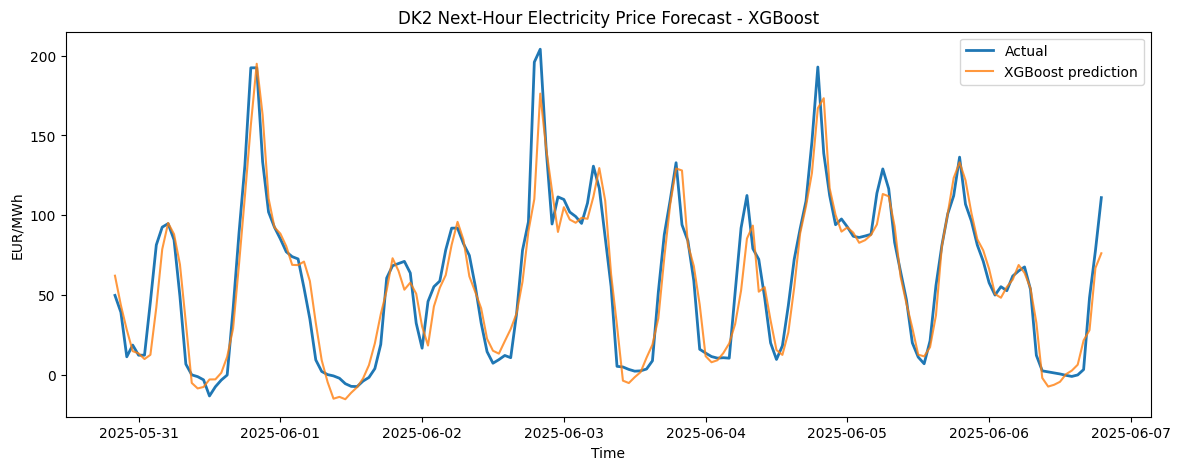

In [14]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_next_hour"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_xgboost"],
    label="XGBoost prediction",
    alpha=0.8
)

plt.title("DK2 Next-Hour Electricity Price Forecast - XGBoost")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [15]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
5,SpotPriceEUR,0.239178
27,net_load_mwh,0.186900
31,PowerToHeatMWh,0.065444
20,LocalPowerMWh,0.050428
10,price_rolling_std_24h,0.050171
19,CentralPowerMWh,0.038125
26,renewable_generation_mwh,0.035886
6,price_lag_24h,0.033683
9,price_rolling_mean_24h,0.029267
21,CommercialPowerMWh,0.027950


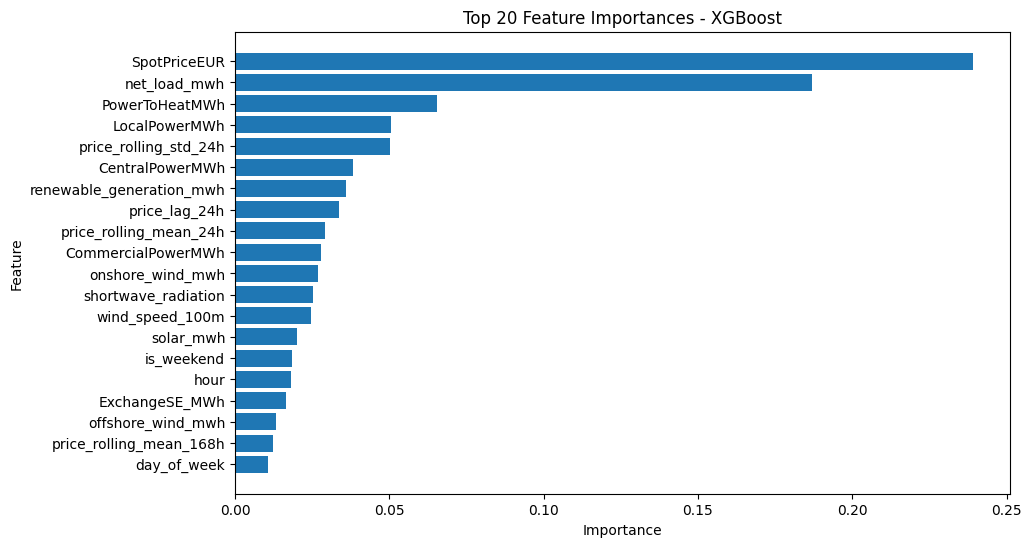

In [16]:
top_importance = importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclusion

The XGBoost model achieved the best performance among the tested models, with a MAE of 9.78 EUR/MWh and an RMSE of 16.56 EUR/MWh.

Compared with the strongest baseline, the current price baseline, which achieved a MAE of 14.62 EUR/MWh, XGBoost reduced the forecasting error by approximately 33.11%.

This suggests that the model is able to improve over simple short-term price persistence for next-hour electricity price forecasting in DK2.

The feature importance analysis shows that the current spot price is the most influential feature, which is expected for a one-hour-ahead forecast. Other relevant variables include price volatility over the previous week, local and central power production, net load, renewable generation, wind speed, exchanges, solar generation and weekend effects.

A natural next step is to test longer forecast horizons, such as 24-hour-ahead forecasting, where weather, renewable generation, demand and energy fundamentals may become even more important.

In [17]:
print("Best model by MAE:")
display(comparison.iloc[0])

print("XGBoost vs Current Price Baseline:")
baseline_mae = comparison.loc[comparison["model"] == "Current price baseline", "MAE"].values[0]
xgb_mae = comparison.loc[comparison["model"] == "XGBoost", "MAE"].values[0]

improvement = (baseline_mae - xgb_mae) / baseline_mae * 100
print(f"Improvement vs baseline: {improvement:.2f}%")

Best model by MAE:


model    XGBoost
MAE        10.07
RMSE       17.01
Name: 0, dtype: object

XGBoost vs Current Price Baseline:
Improvement vs baseline: 31.12%
